### Notebook used to visualize the generated datasets

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches
from ipywidgets import interact, IntSlider, Dropdown, Layout, Checkbox, VBox, HBox

In [2]:
facies_properties = {
    'undefined':           {'val': 0,  'color': "#ff0000", 'grain_size': 0,  'porosity_class': 0,    'description': "Background/Undefined"},
    'channel_lag':         {'val': 1,  'color': "#f1970f", 'grain_size': 13, 'porosity_class': -2,   'description': "Active channel fill, coarse-grained"},
    'point_bar':           {'val': 2,  'color': "#f3dd12", 'grain_size': 10, 'porosity_class': 1,    'description': "Lower energy channel margins"},
    'sand_plug':           {'val': 3,  'color': "#af8f00", 'grain_size': 9,  'porosity_class': 2,    'description': "Fine-grained oxbow/plug fill"},
    'crevasse_splay_core': {'val': 4,  'color': "#fffc65", 'grain_size': 9,  'porosity_class': 2,    'description': "Proximal high-energy splay"},
    'crevasse_channel':    {'val': 5,  'color': "#ffd986", 'grain_size': 8,  'porosity_class': 3,    'description': "Feeder channel for splays"},
    'crevasse_splay_delta':{'val': 6,  'color': "#ff9853", 'grain_size': 7,  'porosity_class': 2,    'description': "Distal fan-like splay deposit"},
    'levee':               {'val': 7,  'color': "#27ae60", 'grain_size': 6,  'porosity_class': 5,    'description': "Sand/silt ridges bordering channel"},
    'overbank':            {'val': 8,  'color': "#33ff00", 'grain_size': 3,  'porosity_class': 8,    'description': "Stabilized/vegetated levee"},
    'mud_plug':            {'val': 9,  'color': "#fff7db", 'grain_size': 2,  'porosity_class': 10.5, 'description': "Fine silts/clays far from channel"},
    'hemipelagic_plug':    {'val': 10, 'color': "#7a7d80", 'grain_size': 2,  'porosity_class': 10.5, 'description': "Silts near active channel belts"},
    'wetland':             {'val': 11, 'color': "#d862f0", 'grain_size': 1,  'porosity_class': 12.5, 'description': "Organic rich, very fine sediment"},
    'draping':             {'val': 12, 'color': "#8dd5e7", 'grain_size': 1,  'porosity_class': 12.5, 'description': "Lateral accretion sand bodies"},
    'pelagic':             {'val': 13, 'color': "#3498db", 'grain_size': 1,  'porosity_class': 12.5, 'description': "Lacustrine clay/silt"}
}

val_to_info = {
    info['val']: {
        'color': info['color'], 
        'name': key.replace('_', ' ').title() # Converts 'channel_lag' to 'Channel Lag'
    } 
    for key, info in facies_properties.items()
}

## 2D plot

In [3]:
cd "c:\\Users\\mathi\\Desktop\\TU Delft\\TU Delft year 5\\Master Thesis\\Thesis-project-DGM"

c:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM


In [7]:
data = np.load("data\\test_outputs\\sample_1.npz")

data['facies']

array([[[2, 2, 9, ..., 1, 2, 2],
        [2, 2, 9, ..., 2, 2, 2],
        [1, 9, 9, ..., 2, 1, 1],
        ...,
        [7, 7, 7, ..., 2, 6, 6],
        [7, 7, 7, ..., 6, 6, 6],
        [7, 7, 7, ..., 5, 7, 7]],

       [[7, 2, 9, ..., 2, 2, 2],
        [7, 9, 9, ..., 2, 2, 2],
        [2, 9, 9, ..., 1, 2, 2],
        ...,
        [7, 7, 7, ..., 2, 8, 8],
        [7, 7, 7, ..., 2, 8, 8],
        [7, 7, 7, ..., 2, 8, 8]],

       [[7, 7, 7, ..., 2, 2, 2],
        [7, 7, 7, ..., 2, 2, 1],
        [7, 7, 7, ..., 2, 2, 2],
        ...,
        [8, 8, 8, ..., 2, 2, 7],
        [8, 8, 8, ..., 2, 7, 7],
        [8, 8, 8, ..., 2, 7, 7]],

       ...,

       [[9, 9, 9, ..., 1, 1, 2],
        [9, 9, 9, ..., 1, 1, 1],
        [9, 9, 9, ..., 2, 1, 1],
        ...,
        [2, 2, 2, ..., 2, 2, 2],
        [2, 2, 2, ..., 2, 2, 2],
        [2, 2, 2, ..., 2, 2, 2]],

       [[9, 9, 9, ..., 2, 2, 1],
        [9, 9, 9, ..., 2, 2, 2],
        [9, 9, 9, ..., 2, 2, 2],
        ...,
        [1, 2, 2, ..., 

In [ ]:
def create_interactive_viewer(file_path, is_one_hot=False):
    # Load data once to get dimensions
    data = np.load(file_path)
    fac_data = data['facies']
    if is_one_hot and fac_data.ndim == 4:
        fac_vol = np.argmax(fac_data, axis=0)
    else:
        fac_vol = fac_data[0] if fac_data.ndim == 4 else fac_data
    
    nz, ny, nx = fac_vol.shape
    unique_facies = np.sort(np.unique(fac_vol))
    
    # Pre-calculate colors for the colormap
    current_colors = [val_to_info[v]['color'] if v in val_to_info else "#333333" for v in unique_facies]
    cmap = ListedColormap(current_colors)
    norm = BoundaryNorm(np.append(unique_facies, unique_facies[-1] + 1) - 0.5, len(unique_facies))

    def update_plot(axis, index):
        plt.figure(figsize=(12, 7))
        
        # Slicing
        if axis == 'Z (Map View)':
            slc = fac_vol[index, :, :]
            ylabel, xlabel = "y (North)", "x (East)"
        elif axis == 'Y (XS East-West)':
            slc = fac_vol[:, index, :]
            ylabel, xlabel = "z (Depth)", "x (East)"
        else: # X
            slc = fac_vol[:, :, index]
            ylabel, xlabel = "z (Depth)", "y (North)"

        plt.imshow(slc, origin='lower', cmap=cmap, norm=norm, aspect='auto')
        
        # Legend
        vals_in_slice = np.unique(slc)
        legend_elements = [mpatches.Patch(facecolor=val_to_info[v]['color'], label=f"({v}) {val_to_info[v]['name']}") 
                           for v in vals_in_slice if v in val_to_info]
        
        plt.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1, 0.5), title="Facies")
        plt.title(f"FLUMY Slice: {axis} at Index {index}", fontsize=14)
        plt.ylabel(ylabel)
        plt.xlabel(xlabel)
        plt.show()

    # Create UI Elements
    axis_dropdown = Dropdown(options=['Z (Map View)', 'Y (XS East-West)', 'X (XS North-South)'], value='Z (Map View)', description='Axis:')
    
    # Dynamic slider range based on axis selection
    index_slider = IntSlider(min=0, max=nz-1, step=1, value=nz//2, description='Slice:', layout=Layout(width='50%'))

    def on_axis_change(change):
        if change['new'] == 'Z (Map View)':
            index_slider.max = nz - 1
        elif change['new'] == 'Y (XS East-West)':
            index_slider.max = ny - 1
        else:
            index_slider.max = nx - 1
        index_slider.value = index_slider.max // 2

    axis_dropdown.observe(on_axis_change, names='value')

    interact(update_plot, axis=axis_dropdown, index=index_slider)

# --- Usage ---
# In a Jupyter Notebook cell:

base = "data\\test_outputs"
create_interactive_viewer(os.path.join(base, "sample_1.npz"))

interactive(children=(Dropdown(description='Axis:', options=('Z (Map View)', 'Y (XS East-West)', 'X (XS North-…

## 3D plot

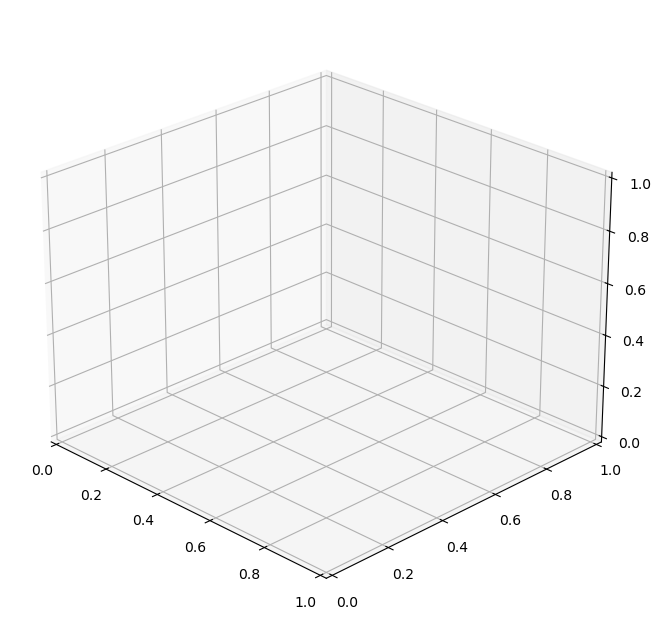

interactive(children=(IntSlider(value=64, description='X', max=127), IntSlider(value=64, description='Y', max=…

In [10]:
def visualize_3d_smooth(file_path, is_one_hot=False):
    # --- 1. Load and Cache Data ---
    data = np.load(file_path)
    fac_data = data['facies']
    fac_vol = np.argmax(fac_data, axis=0) if (is_one_hot and fac_data.ndim == 4) else (fac_data[0] if fac_data.ndim == 4 else fac_data)
    
    nz, ny, nx = fac_vol.shape
    unique_facies = np.sort(np.unique(fac_vol))
    
    # --- 2. Setup Colormap ---
    current_colors = [val_to_info[v]['color'] if v in val_to_info else "#333333" for v in unique_facies]
    cmap = ListedColormap(current_colors)
    norm = BoundaryNorm(np.append(unique_facies, unique_facies[-1] + 1) - 0.5, len(unique_facies))

    # Pre-generate grids once to save CPU
    x_coords, y_coords, z_coords = np.arange(nx), np.arange(ny), np.arange(nz)
    gz_x, gz_y = np.meshgrid(x_coords, y_coords)
    gy_x, gy_z = np.meshgrid(x_coords, z_coords)
    gx_y, gx_z = np.meshgrid(y_coords, z_coords)

    # Create the persistent figure
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.view_init(elev=25, azim=-45)

    def update_plot(x_idx, y_idx, z_idx, show_x, show_y, show_z):
        ax.clear() # Clear only the axes content, not the whole figure object
        
        # We use 'continuous_update=True' in the sliders for smoothness
        # and re-render only the active planes.
        
        if show_z:
            ax.contourf(gz_x, gz_y, fac_vol[z_idx, :, :], 
                        zdir='z', offset=z_idx, cmap=cmap, norm=norm, alpha=0.9)
        if show_y:
            ax.contourf(gy_x, fac_vol[:, y_idx, :], gy_z, 
                        zdir='y', offset=y_idx, cmap=cmap, norm=norm, alpha=0.9)
        if show_x:
            ax.contourf(fac_vol[:, :, x_idx], gx_y, gx_z, 
                        zdir='x', offset=x_idx, cmap=cmap, norm=norm, alpha=0.9)

        ax.set_xlim(0, nx); ax.set_ylim(0, ny); ax.set_zlim(0, nz)
        ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
        
        # Only show legend for what's in the volume to save space
        legend_elements = [mpatches.Patch(facecolor=val_to_info[v]['color'], label=val_to_info[v]['name']) 
                           for v in unique_facies if v in val_to_info]
        ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.1, 1))
        
        fig.canvas.draw_idle() # Optimized redraw for interactive backends

    # --- 3. Interaction with continuous_update=True ---
    interact(update_plot, 
             x_idx=IntSlider(min=0, max=nx-1, value=nx//2, continuous_update=True, description='X'),
             y_idx=IntSlider(min=0, max=ny-1, value=ny//2, continuous_update=True, description='Y'),
             z_idx=IntSlider(min=0, max=nz-1, value=nz//2, continuous_update=True, description='Z'),
             show_x=Checkbox(value=True, description='Show X'),
             show_y=Checkbox(value=True, description='Show Y'),
             show_z=Checkbox(value=True, description='Show Z'))

visualize_3d_smooth(os.path.join(base, "sample_1.npz"))

## Ananlyse all samples:

In [11]:
linux_base = "data//test_outputs"
files = [f for f in os.listdir(linux_base) if f.endswith('.npz')]
print(f"Found {len(files)} files to process.")

Found 1 files to process.


Crunching the data...

Processing complete! Calculating distribution...

--- Overall Facies Distribution ---
[ 1] Channel Lag           :   5.78% (60,618 voxels)
[ 2] Point Bar             :  50.43% (528,802 voxels)
[ 3] Sand Plug             :   7.86% (82,400 voxels)
[ 4] Crevasse Splay Core   :   0.19% (2,044 voxels)
[ 5] Crevasse Channel      :   1.14% (11,919 voxels)
[ 6] Crevasse Splay Delta  :   0.17% (1,763 voxels)
[ 7] Levee                 :  11.56% (121,258 voxels)
[ 8] Overbank              :   2.86% (30,035 voxels)
[ 9] Mud Plug              :  19.96% (209,333 voxels)
[11] Wetland               :   0.04% (404 voxels)


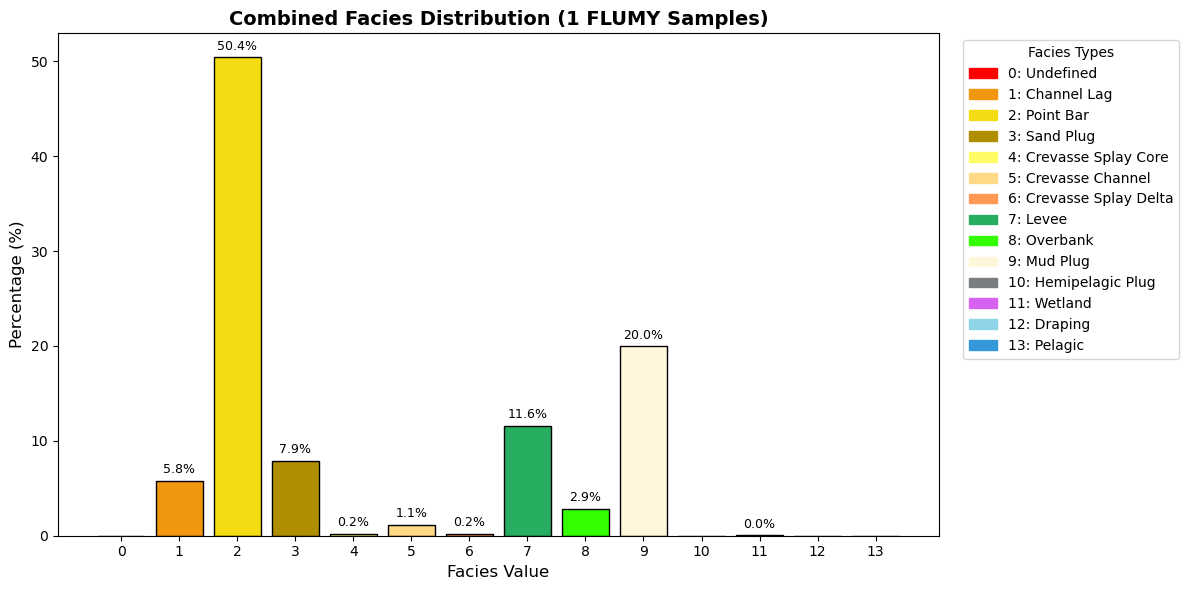

In [12]:
total_counts = np.zeros(14, dtype=np.int64)
print("Crunching the data...")

for i, f in enumerate(files):
    filepath = os.path.join(base, f)
    with np.load(filepath) as data:
        grid = data['facies']
        # Extract counts, forcing length to 14 (values 0-13)
        file_counts = np.bincount(grid.ravel(), minlength=14)
        total_counts += file_counts

    if (i + 1) % 100 == 0:
        print(f"Processed {i + 1}/{len(files)} files...")

print("\nProcessing complete! Calculating distribution...")

# Calculate percentages
total_voxels = total_counts.sum()
percentages = (total_counts / total_voxels) * 100

# Print formatted text output with Facies Names
print("\n--- Overall Facies Distribution ---")
for val in range(14):
    if total_counts[val] > 0:
        facies_name = val_to_info[val]['name']
        print(f"[{val:2d}] {facies_name:<22}: {percentages[val]:6.2f}% ({total_counts[val]:,} voxels)")


# --- Visualization ---
plt.figure(figsize=(12, 6)) # Made slightly wider to fit the legend

x_values = np.arange(14)
# Map the colors from the dictionary to a list in order from 0 to 13
bar_colors = [val_to_info[val]['color'] for val in x_values]

# Create the bar chart
bars = plt.bar(x_values, percentages, color=bar_colors, edgecolor='black')

# Add data labels on top of the bars
for bar in bars:
    height = bar.get_height()
    if height > 0: 
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                 f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

# Build custom legend handles using the dictionary
legend_patches = [
    mpatches.Patch(color=val_to_info[val]['color'], label=f"{val}: {val_to_info[val]['name']}")
    for val in x_values
]


plt.legend(handles=legend_patches, title="Facies Types", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
plt.title(f'Combined Facies Distribution ({len(files)} FLUMY Samples)', fontsize=14, weight='bold')
plt.xlabel('Facies Value', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(x_values) 
plt.tight_layout()
# plt.savefig('facies_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import shutil
import matplotlib.font_manager as fm

my_font_path = r"C:\Users\mathi\Downloads\Bebas_Neue,Montserrat,Source_Sans_3\Source_Sans_3\SourceSans3-VariableFont_wght.ttf"
fm.fontManager.addfont(my_font_path)

def apply_custom_plotting_flavor():
    """
    Applies the custom plotting style inspired by the supervisor's notebook.
    Features thin lines, grey ticks, LaTeX text formatting, and no top/right spines.
    """
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = 'Source Sans 3'
    plt.rcParams['font.size'] = 8
    
    # NOTE: Set to False if you don't have a local LaTeX installation
    plt.rcParams['text.usetex'] = False

    plt.rcParams['figure.constrained_layout.use'] = False
    plt.rcParams['figure.titlesize'] = 9

    # Axis and edge coloring (sleek grey instead of black)
    plt.rcParams['axes.edgecolor'] = '#8C8C8C'
    plt.rcParams['axes.labelcolor'] = '#595959'
    plt.rcParams['axes.linewidth'] = 0.4
    plt.rcParams['axes.labelsize'] = 9
    plt.rcParams['axes.spines.right'] = False
    plt.rcParams['axes.spines.top'] = False
    plt.rcParams['axes.titlecolor'] = 'black'
    plt.rcParams['axes.titlesize'] = 9
    
    # Tick formatting
    plt.rcParams['xtick.color'] = '#8C8C8C'
    plt.rcParams['xtick.labelsize'] = 8
    plt.rcParams['xtick.major.pad'] = 3
    plt.rcParams['xtick.major.size'] = 3
    plt.rcParams['xtick.major.width'] = 0.4
    plt.rcParams['xtick.minor.pad'] = 3
    plt.rcParams['xtick.minor.size'] = 1.5
    plt.rcParams['xtick.minor.width'] = 0.4
    
    plt.rcParams['ytick.color'] = '#8C8C8C'
    plt.rcParams['ytick.labelsize'] = 8
    plt.rcParams['ytick.major.pad'] = 3
    plt.rcParams['ytick.major.size'] = 3
    plt.rcParams['ytick.major.width'] = 0.4
    plt.rcParams['ytick.minor.pad'] = 3
    plt.rcParams['ytick.minor.size'] = 1.5
    plt.rcParams['ytick.minor.width'] = 0.4

    # Grid formatting
    plt.rcParams['grid.color'] = '#BFBFBF'
    plt.rcParams['grid.alpha'] = 0.5
    plt.rcParams['grid.linewidth'] = 0.2

    # Line formatting
    plt.rcParams['lines.linewidth'] = 0.6

def plot_facies_distribution(x_samples=10):
    """
    Generates a plot showing the facies distribution (FA1, FA2, FA3) 
    for a given number of simulated samples.
    """
    # 1. Apply the aesthetic flavor
    apply_custom_plotting_flavor()
    
    # Supervisor's color palette
    palette = ['#003f5c', '#bc5090', '#ffa600'] 
    
    # 2. Simulate some dummy data for X samples (e.g., volume percentage of each facies)
    # Replace this block with your actual Flumy data processing
    np.random.seed(42)
    fa1 = np.random.normal(loc=30, scale=5, size=x_samples) # Fluvial channels
    fa2 = np.random.normal(loc=20, scale=4, size=x_samples) # Crevasse splays
    fa3 = 100 - (fa1 + fa2)                                 # Overbank deposits
    
    samples_idx = np.arange(1, x_samples + 1)
    
    # 3. Create the figure
    fig, ax = plt.subplots(figsize=(6, 3.5), dpi=150)
    
    # Stacked Bar Chart for the distribution
    width = 0.6
    ax.bar(samples_idx, fa1, width, label='FA1: Channel Deposits', color=palette[0], edgecolor='none')
    ax.bar(samples_idx, fa2, width, bottom=fa1, label='FA2: Crevasse/Levee', color=palette[1], edgecolor='none')
    ax.bar(samples_idx, fa3, width, bottom=fa1+fa2, label='FA3: Overbank/Paleosols', color=palette[2], edgecolor='none')
    
    # 4. Styling the plot
    ax.set_xlabel('Sample ID')
    ax.set_ylabel('Facies Distribution (\%)')
    ax.set_title(f'Overview of Facies Distributions Across {x_samples} Samples')
    
    # X-ticks adjustment
    ax.set_xticks(samples_idx)
    if x_samples > 15:
        ax.set_xticks(samples_idx[::int(x_samples/10)]) # prevent overcrowding
    
    # Grid and legend
    ax.grid(axis='y', linestyle='--')
    ax.set_axisbelow(True) # Ensure grid is behind bars
    
    # Customize legend
    # Customize legend - Moved to the bottom
    legend = ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), 
                       frameon=False, fontsize=8, ncol=3)
    
    for text in legend.get_texts():
        text.set_color('#595959') # Match text color to axes
    
    # Show and return
    plt.tight_layout()
    plt.show()

# Run the function to test your new style
plot_facies_distribution(x_samples=15)